In [1]:
from sklearn.preprocessing import StandardScaler
from utils import *
from linear_regression import *

## Load data

In [2]:
data_path = '../data/processed/'
X_train = load_data(f'{data_path}/X_train.csv').values
X_val = load_data(f'{data_path}/X_val.csv').values
X_test = load_data(f'{data_path}/X_test.csv').values
y_train = load_data(f'{data_path}/y_train.csv').values
y_val = load_data(f'{data_path}/y_val.csv').values
y_test = load_data(f'{data_path}/y_test.csv').values

## Train Linear Regression with sklearn

In [3]:
lr_sklearn = LinearRegressionSklearn()
lr_sklearn.fit(X_train, y_train)

In [4]:
test_model(lr_sklearn, X_val, y_val)
test_model(lr_sklearn, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 376.1353
R^2 Score: 0.4875

========= Model Evaluation =========
Mean Squared Error (MSE): 351.8113
R^2 Score: 0.5457


## Normalize data for later training 

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Train Linear Regression using Numpy

In [6]:
lr_numpy = LinearRegressionNumpy(n_features=X_train.shape[1], lr=0.01)
train_losses, val_losses = lr_numpy.fit(X_train, y_train, X_val, y_val, epochs=1000)

Epoch [100/1000], Train Loss: 4738.4983, Val Loss: 4755.9730
Epoch [200/1000], Train Loss: 971.3025, Val Loss: 977.6681
Epoch [300/1000], Train Loss: 464.4993, Val Loss: 463.2570
Epoch [400/1000], Train Loss: 394.9127, Val Loss: 391.3972
Epoch [500/1000], Train Loss: 384.3041, Val Loss: 380.8468
Epoch [600/1000], Train Loss: 381.8351, Val Loss: 379.1252
Epoch [700/1000], Train Loss: 380.6163, Val Loss: 378.7386
Epoch [800/1000], Train Loss: 379.6845, Val Loss: 378.5512
Epoch [900/1000], Train Loss: 378.8867, Val Loss: 378.3838
Epoch [1000/1000], Train Loss: 378.1861, Val Loss: 378.2136


In [7]:
test_model(lr_numpy, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 347.7374
R^2 Score: 0.5510


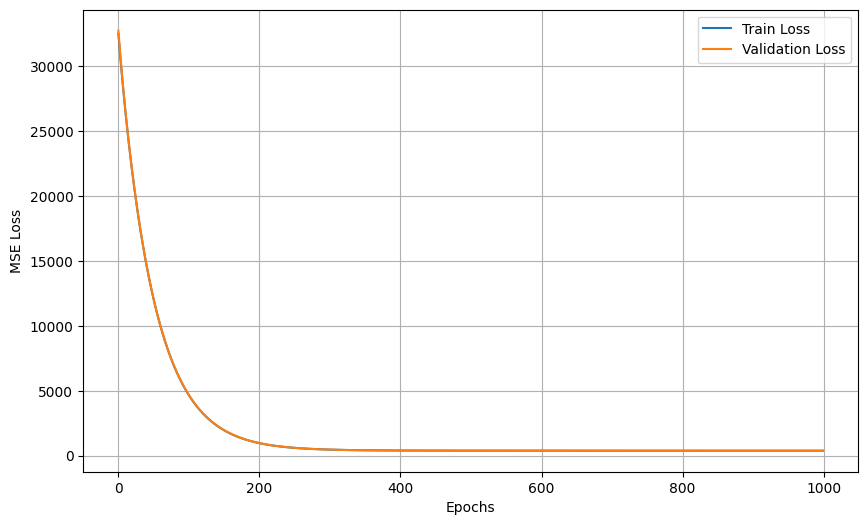

In [8]:
plot_loss(train_losses, val_losses)

## Train Linear Regression using Torch

In [9]:
lr_torch = LinearRegressionTorch(X_train.shape[1], lr=0.01)
train_losses, val_losses = lr_torch.fit(X_train, y_train, X_val, y_val, epochs=1000)

Epoch [100/1000], Train Loss: 972.3006, Val Loss: 964.8262
Epoch [200/1000], Train Loss: 395.0184, Val Loss: 390.7997
Epoch [300/1000], Train Loss: 382.0692, Val Loss: 379.1528
Epoch [400/1000], Train Loss: 379.8686, Val Loss: 378.6296
Epoch [500/1000], Train Loss: 378.3257, Val Loss: 378.3061
Epoch [600/1000], Train Loss: 377.1190, Val Loss: 377.9789
Epoch [700/1000], Train Loss: 376.1577, Val Loss: 377.6866
Epoch [800/1000], Train Loss: 375.3823, Val Loss: 377.4439
Epoch [900/1000], Train Loss: 374.7511, Val Loss: 377.2494
Epoch [1000/1000], Train Loss: 374.2327, Val Loss: 377.0966


In [10]:
test_model(lr_torch, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 348.6175
R^2 Score: 0.5499


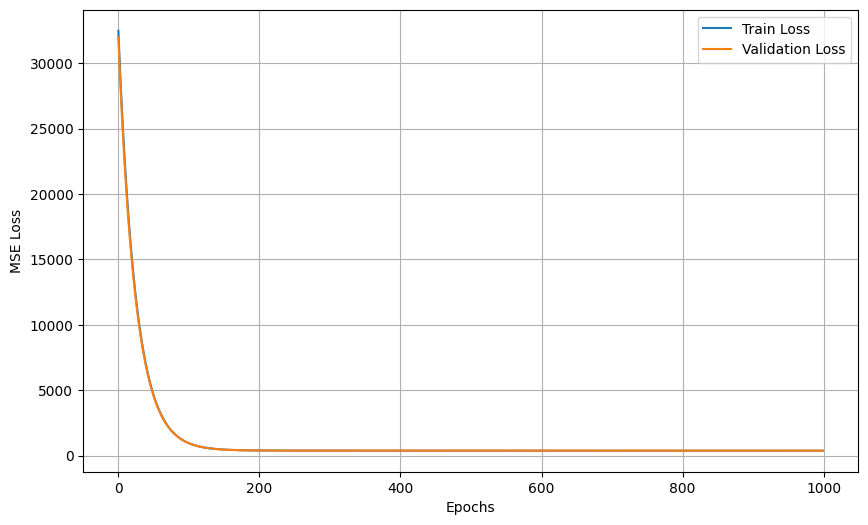

In [11]:
plot_loss(train_losses, val_losses)